<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/galaxy_SPT0346_52.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Galaxy SPT0346-52**

In [ ]:
!pip install astropy photutils astroquery lightkurve -q

from astropy import units as u
from astroquery.ipac.irsa import Irsa
import lightkurve as lk
from astroquery.vizier import Vizier
from astropy.coordinates import Angle
from astroquery.splatalogue import Splatalogue
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline

In [2]:
# Access infrared data from JWS instruments
from astroquery.mast import Observations

# Set up the query parameters
obs_table = Observations.query_criteria(
    obs_collection='JWST',           # Specific to JWST
    instrument_name=['NIRCam', 'MIRI', 'NIRSpec', 'NIRISS', 'FGS']
)

# Display the results
print(obs_table)

 intentType obs_collection provenance_name instrument_name ... mtFlag srcDen   obsid     objID  
----------- -------------- --------------- --------------- ... ------ ------ --------- ---------
    science           JWST         CALJWST         NIRSPEC ...  False    nan 107458509 204963674
    science           JWST         CALJWST            MIRI ...  False    nan 102604820 215004479
calibration           JWST         CALJWST             FGS ...  False    nan  71739127 294621945
calibration           JWST         CALJWST             FGS ...  False    nan  78110357 317255586
calibration           JWST         CALJWST             FGS ...  False    nan  71774526 317392654
calibration           JWST         CALJWST             FGS ...  False    nan  71752546 317392663
calibration           JWST         CALJWST             FGS ...  False    nan  71774896 317557360
calibration           JWST         CALJWST             FGS ...  False    nan  71775531 317557535
calibration           JWST    

In [3]:
# Assuming you've selected specific observations (first one for this example)
data = Observations.get_product_list(obs_table[0])

In [4]:
# Instead of downloading, just count unique products
unique_products = len(set(data['productFilename']))

# Print the count of unique products
print(f"Number of unique products: {unique_products}")

Number of unique products: 803


In [5]:
# Show the available data products
print(data)

  obsID   obs_collection dataproduct_type ... dataRights calib_level   filters   
--------- -------------- ---------------- ... ---------- ----------- ------------
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
      ...       

In [ ]:
# Download all data
# Observations.download_products(data)

In [6]:
# Select the first few products to download (e.g., first 5 products)
subset = data[:5]  # Adjust the number as needed

# Download the selected data products
Observations.download_products(subset)

Local Path,Status,Message,URL
str95,str8,object,object
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233957_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq2_2022285233914_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq2_2022285233959_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-fg_2022285235710_cal.fits,COMPLETE,None,None


In [7]:
# Filter table by column value, based on specific criteria, e.g. only observations using NIRCam
nircam_obs = obs_table[obs_table['instrument_name'] == 'MIRI']
print(nircam_obs)

intentType obs_collection provenance_name instrument_name ... mtFlag srcDen   obsid     objID  
---------- -------------- --------------- --------------- ... ------ ------ --------- ---------
   science           JWST         CALJWST            MIRI ...  False    nan 102604820 215004479


The phrase "The Formation of a Primeval Hyperstarburst Galaxy at z~6" refers to a galaxy, not a single star. In astronomy, a "starburst galaxy" is a galaxy undergoing an exceptionally high rate of star formation, often triggered by interactions or mergers with other galaxies. The term "primeval" here suggests that this galaxy is very young or in an early stage of formation.

The redshift \( z \approx 6 \) indicates that this galaxy formed in the very early universe, around 12.8 billion years ago. Such hyperstarburst galaxies are among the first massive structures to form, and they provide clues about galaxy formation and evolution in the early universe.

https://jwstfeed.com/PostView/FeedPost?ci=1674172800_jw01864-o002_t001_miri_f770w

https://www.stsci.edu/jwst/phase2-public/1864.pdf

https://ui.adsabs.harvard.edu/abs/2021jwst.prop.1864P/abstract

In [8]:
# Inspect data

# Specify the path to the FITS file
fits_file = './mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits'

# Open the FITS file
hdul = fits.open(fits_file)

# Print the file information
hdul.info()

Filename: ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   ()      
  1  SCI           1 ImageHDU        56   (128, 128, 6)   float32   
  2  ERR           1 ImageHDU        10   (128, 128, 6)   float32   
  3  DQ            1 ImageHDU        11   (128, 128)   int32 (rescales to uint32)   
  4  ASDF          1 BinTableHDU     11   1R x 1C   [398172B]   


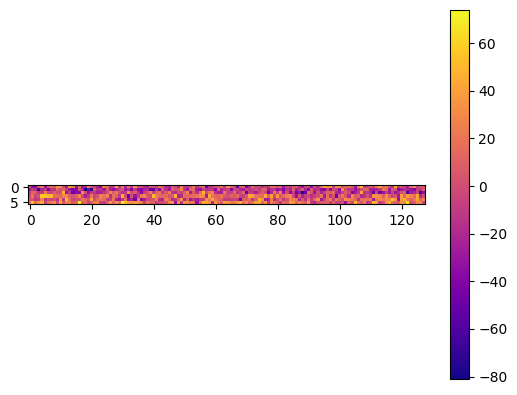

In [9]:
import matplotlib.pyplot as plt

# Plot the first image slice (for the first layer in the 3rd dimension)
plt.imshow(hdul[1].data[:, :, 0], cmap='plasma')
plt.colorbar()
plt.show()

In [10]:
# Access the primary HDU (Header/Data Unit) to get the data
primary_hdu = hdul[0]
data = primary_hdu.data

# Display the header to learn more about the file
print(primary_hdu.header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2022-10-13T06:07:44.279' / UTC date file created                     ORIGIN  = 'STSCI   '           / Organization responsible for creating file     TIMESYS = 'UTC     '           / principal time system for time-related keywordsTIMEUNIT= 's       '           / Default unit applicable to all time values     FILENAME= 'jw01864003001_gs-acq1_2022285233912_cal.fits' / Name of the file     SDP_VER = '2022_3a '           / Data processing software version number        PRD_VER = 'PRDOPSSOC-058'      / S&OC PRD version number used in data processingOSS_VER = '008.004.014.000'    / Observatory Scheduling Software (OSS) version nCAL_VER = '1.7.2   '           / Calibra

In [11]:
print(repr(hdul[1].header))  # Science data HDU header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  128                                                  
NAXIS2  =                  128                                                  
NAXIS3  =                    6                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'SCI     '           / extension name                                 
                                                                                
        JWST ephemeris information                                              
                                                                                
REFFRAME= 'EME2000 '        

In [12]:
print(repr(hdul[0].header))  # Primary HDU header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2022-10-13T06:07:44.279' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01864003001_gs-acq1_2022285233912_cal.fits' / Name of the file     
SDP_VER = '2022_3a '           / Data processing software version number        
PRD_VER = 'PRDOPSSOC-058'      / S&OC PRD version number used in data processing
OSS_VER = '008.004.014.000'    / Observatory Scheduling Software (OSS) version n
CAL_VER = '1.7.2   '        

In [13]:
# Access the primary header
primary_header = hdul[0].header
print(repr(primary_header))  # View primary header contents

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2022-10-13T06:07:44.279' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01864003001_gs-acq1_2022285233912_cal.fits' / Name of the file     
SDP_VER = '2022_3a '           / Data processing software version number        
PRD_VER = 'PRDOPSSOC-058'      / S&OC PRD version number used in data processing
OSS_VER = '008.004.014.000'    / Observatory Scheduling Software (OSS) version n
CAL_VER = '1.7.2   '        

In [14]:
# Access the primary data (if available)
primary_data = hdul[0].data
print(primary_data)  # Will print the data array if it exists (might be large)

None


In [15]:
# If there are more extensions, you can explore them:
# Example: access extension 1's header and data
if len(hdul) > 1:
    extension_header = hdul[1].header
    print(repr(extension_header))

    extension_data = hdul[1].data
    print(extension_data)

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  128                                                  
NAXIS2  =                  128                                                  
NAXIS3  =                    6                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'SCI     '           / extension name                                 
                                                                                
        JWST ephemeris information                                              
                                                                                
REFFRAME= 'EME2000 '        

In [16]:
# Check if there is data
if data is not None:
    # Show the dimensions of the data
    print(f"Data shape: {data.shape}")

    # Display the image if it is 2D
    if data.ndim == 2:
        plt.figure(figsize=(10, 8))
        plt.imshow(data, origin='lower', cmap='viridis')
        plt.colorbar()
        plt.title("All Sky ROSAT FITS Image")
        plt.show()
    else:
        print("Data is not 2D, unable to display as an image.")
else:
    print("No data found in the primary HDU.")

# Close the FITS file after you're done
hdul.close()

No data found in the primary HDU.


In [ ]:
# Close the FITS file when done
hdul.close()